<a href="https://colab.research.google.com/github/francji1/01RAD/blob/main/code/01RAD_Ex01_HW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 01RAD - Homework 01: Cars braking distance

Investigate the relationship between the speed of a car and its stopping distance using the classic `cars` dataset (50 observations recorded in the 1920s: `speed` in mph, `dist` in ft).

Use the notation of Lecture 1: model $Y_i = \beta_0 + \beta_1 x_i + e_i$, least squares estimates $\widehat{\beta}_0, \widehat{\beta}_1$, residuals $\widehat{e}_i$, unbiased variance estimate $s_n^2 = SSE/(n-2)$.

## Submission
Work through the tasks below in this notebook (code plus short written answers in markdown cells). Python is the default, but you may equally solve the tasks in R (`lm(dist ~ speed, data = cars)`), the questions are the same.

Submit your solution through GitHub **before the next exercise**:
1. fork the course repository `francji1/01RAD`,
2. save your notebook into the `HW/` folder as `01RAD_Ex01_HW_<Surname>.ipynb` (for example `01RAD_Ex01_HW_Novak.ipynb`; for a team join the surnames with an underscore),
3. open a pull request to the `main` branch of `francji1/01RAD`.

A selected student solution and a reference solution will be published in the `HW/` folder a week later.

## Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_theme(style='whitegrid', palette='deep')

url_cars = 'https://raw.githubusercontent.com/francji1/01RAD/main/data/cars.csv'
try:
    cars = pd.read_csv(url_cars)
except Exception:
    # fallback: the same data set from R's datasets package via statsmodels
    cars = sm.datasets.get_rdataset('cars', package='datasets').data
print(f'Rows: {cars.shape[0]}, columns: {cars.shape[1]}')
cars.head()

Rows: 50, columns: 2


,speed,dist
0,4,2
1,4,10
2,7,4
3,7,22
4,8,16


## Task 01 - Inspect the data
Inspect the structure of the dataset (`info()`, `describe()`). Which variable is the response and which the explanatory variable here, and why?

In [2]:
# your solution
cars.info()
cars.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   speed   50 non-null     int64
 1   dist    50 non-null     int64
dtypes: int64(2)
memory usage: 932.0 bytes


,speed,dist
count,50.000000,50.000000
mean,15.400000,42.980000
std,5.287644,25.769377
min,4.000000,2.000000
25%,12.000000,26.000000
50%,15.000000,36.000000
75%,19.000000,56.000000
max,25.000000,120.000000


The response is dist and speed is the explanatory variable, because the stopping distance depends on the speed.

## Task 02 - Plots
Plot histograms with density curves for `speed` and `dist`, and the scatter plot of `dist` against `speed`. Comment on the shape of the relationship.

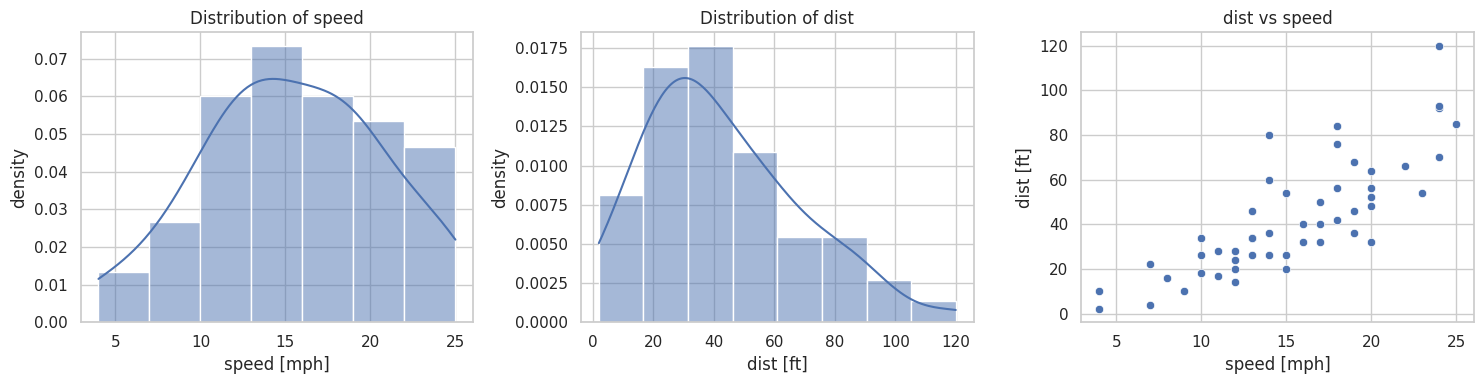

In [3]:
# your solution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(cars['speed'], kde=True, stat='density', ax=axes[0])
axes[0].set(title='Distribution of speed', xlabel='speed [mph]', ylabel='density')

sns.histplot(cars['dist'], kde=True, stat='density', ax=axes[1])
axes[1].set(title='Distribution of dist', xlabel='dist [ft]', ylabel='density')

sns.scatterplot(data=cars, x='speed', y='dist', ax=axes[2])
axes[2].set(title='dist vs speed', xlabel='speed [mph]', ylabel='dist [ft]')

plt.tight_layout()
plt.show()


speed is roughly symmetric, while dist is right-skewed with a few long stopping distances. The scatter plot shows a clear positive relationship: faster cars need longer to stop. The trend is roughly linear, but the points curve slightly upward and spread out more at higher speeds.

## Task 03 - Least squares by hand
Fit the simple linear regression model manually, both with intercept ($Y_i = \beta_0 + \beta_1 x_i + e_i$) and without intercept ($Y_i = \beta_1 x_i + e_i$, regression through the origin). Derive $\widehat{\beta}_0$ and $\widehat{\beta}_1$ from the sums (Lecture 1, formula (2.1)); for the model without intercept derive the estimate from its single normal equation. *Hint:* minimising $\sum_i (y_i - \beta_1 x_i)^2$ gives $\widehat{\beta}_1 = \sum_i x_i y_i / \sum_i x_i^2$, see Exercise 01, section 8.

Setting $\partial S/\partial\beta_0 = 0$ gives $\hat\beta_0 = \bar y - \hat\beta_1 \bar x$, and substituting it into $\partial S/\partial\beta_1 = 0$ gives formula (2.1). Without intercept there is a single normal equation, $\sum_i x_i (y_i - \beta_1 x_i) = 0$, hence $\hat\beta_1 = \sum_i x_i y_i / \sum_i x_i^2$.

In [4]:
# your solution
x = cars['speed'].to_numpy(dtype=float)
y = cars['dist'].to_numpy(dtype=float)
n = len(x)
x_bar, y_bar = x.mean(), y.mean()

# with intercept:
b1 = (np.sum(x * y) - n * x_bar * y_bar) / (np.sum(x**2) - n * x_bar**2)
b0 = y_bar - b1 * x_bar

# Through origin:
b1_0 = np.sum(x * y) / np.sum(x**2)

print(f'With intercept:  b0 = {b0:.4f},  b1 = {b1:.4f}')
print(f'Through origin:  b1 = {b1_0:.4f}')

With intercept:  b0 = -17.5791,  b1 = 3.9324
Through origin:  b1 = 2.9091


## Task 04 - Residual sum of squares and $s_n^2$
Compute the residual sum of squares $SSE$ and the unbiased estimate of the error variance for each model. Mind the degrees of freedom: $n-2$ with intercept, $n-1$ without.

In [5]:
# your solution
res1 = y - (b0 + b1 * x)        # residuals, model with intercept
res0 = y - b1_0 * x              # residuals, model through origin

SSE1 = np.sum(res1**2)
SSE0 = np.sum(res0**2)
s2_1 = SSE1 / (n - 2)            # 2 estimated parameters
s2_0 = SSE0 / (n - 1)            # 1 estimated parameter

print(f'With intercept:  SSE = {SSE1:.2f}, s_n^2 = {s2_1:.2f}, s_n = {np.sqrt(s2_1):.2f}')
print(f'Through origin:  SSE = {SSE0:.2f}, s_n^2 = {s2_0:.2f}, s_n = {np.sqrt(s2_0):.2f}')

With intercept:  SSE = 11353.52, s_n^2 = 236.53, s_n = 15.38
Through origin:  SSE = 12953.78, s_n^2 = 264.36, s_n = 16.26


## Task 05 - Standard errors
Derive the estimated variances and standard errors of the estimated parameters in both models. Check them against `statsmodels` (`.bse`). *Hint:* for the model with intercept use the formulas previewed in Exercise 01, section 7; for the model through the origin $\mathrm{Var}(\widehat{\beta}_1) = \sigma^2 / \sum_i x_i^2$, with $\sigma^2$ estimated by $s_n^2$ on $n-1$ degrees of freedom.

In [6]:
# your solution
S_xx = np.sum((x - x_bar)**2)

# Model with intercept
var_b1 = s2_1 / S_xx
var_b0 = s2_1 * (1/n + x_bar**2 / S_xx)
# Model through the origin
var_b1_0 = s2_0 / np.sum(x**2)

print(f'With intercept:  Var(b0) = {var_b0:.3f}, SE(b0) = {np.sqrt(var_b0):.4f}')
print(f'                 Var(b1) = {var_b1:.4f}, SE(b1) = {np.sqrt(var_b1):.4f}')
print(f'Through origin:  Var(b1) = {var_b1_0:.5f}, SE(b1) = {np.sqrt(var_b1_0):.4f}')

# check against statsmodels
m1 = smf.ols('dist ~ speed', data=cars).fit()
m0 = smf.ols('dist ~ speed - 1', data=cars).fit()
print('statsmodels .bse:', m1.bse.round(4).to_dict(), m0.bse.round(4).to_dict())

With intercept:  Var(b0) = 45.677, SE(b0) = 6.7584
                 Var(b1) = 0.1727, SE(b1) = 0.4155
Through origin:  Var(b1) = 0.01999, SE(b1) = 0.1414
statsmodels .bse: {'Intercept': 6.7584, 'speed': 0.4155} {'speed': 0.1414}


## Task 06 - Fitted lines
Plot the data together with both fitted regression lines on the same axes.

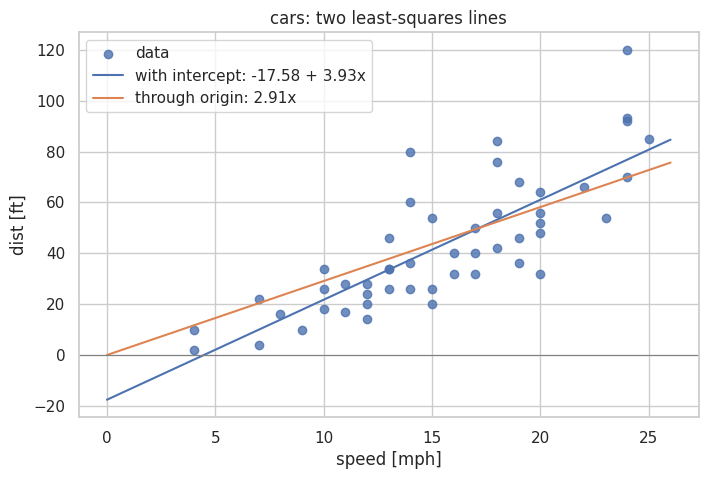

In [7]:
# your solution
grid = np.linspace(0, 26, 200)
plt.figure(figsize=(8, 5))
plt.scatter(x, y, label='data', alpha=0.8)
plt.plot(grid, b0 + b1 * grid, label=f'with intercept: {b0:.2f} + {b1:.2f}x')
plt.plot(grid, b1_0 * grid, label=f'through origin: {b1_0:.2f}x')
plt.axhline(0, color='grey', lw=0.8)
plt.xlabel('speed [mph]'); plt.ylabel('dist [ft]')
plt.title('cars: two least-squares lines'); plt.legend(); plt.show()

## Task 07 - Compare the slopes
Compare the two slopes. Why do they differ? Which model makes more physical sense for braking distance, and what does the sign of $\widehat{\beta}_0$ tell you?

The slope is 3.93 ft/mph with intercept and 2.91 ft/mph through the origin.

Why they differ: the model with intercept can cross the y-axis wherever it fits best, and the best fit crosses at about −17.6 ft, which makes the line steeper. When the line is forced through (0, 0), its left end is pulled up, so it has to be flatter to stay close to the data.

Physical sense: a car standing still needs no distance to stop, so a line through the origin makes more physical sense.

Sign of $\hat\beta_0$: taken literally, the negative intercept would mean that a car at 0 mph stops at −17.6 ft, which is impossible. It is a sign that the straight line is the wrong functional form, not a prediction, since zero speed lies far outside the observed range of 4–25 mph.

## Task 08 - Prediction
Predict the stopping distance at 20 mph and 30 mph with both models. Are the predictions plausible? Which one is an extrapolation?

In [8]:
# your solution
new_speed = np.array([20, 30])
pred = pd.DataFrame({
    'speed': new_speed,
    'with intercept': b0 + b1 * new_speed,
    'through origin': b1_0 * new_speed,
})
print(pred.round(2))
print('observed speed range:', x.min(), '-', x.max())
print('observed dist at speed 20:', y[x == 20])

   speed  with intercept  through origin
0     20           61.07           58.18
1     30          100.39           87.27
observed speed range: 4.0 - 25.0
observed dist at speed 20: [32. 48. 52. 56. 64.]


At 20 mph the models predict 61 ft (with intercept) and 58 ft (through the origin). Both are plausible: 20 mph lies inside the observed range of 4–25 mph and the measured distances at this speed are 32–64 ft, so this is interpolation.

At 30 mph the predictions are 100 ft and 87 ft. This is an extrapolation, since the fastest car in the data drove 25 mph and we cannot check whether the linear trend still holds there. The two models already differ by 13 ft, which shows how uncertain extrapolation is.

## Task 09 - Residuals
Compute and plot the residuals $\widehat{e}_i$ against the fitted values for both models. Which residual pattern looks healthier, and what does the pattern suggest?

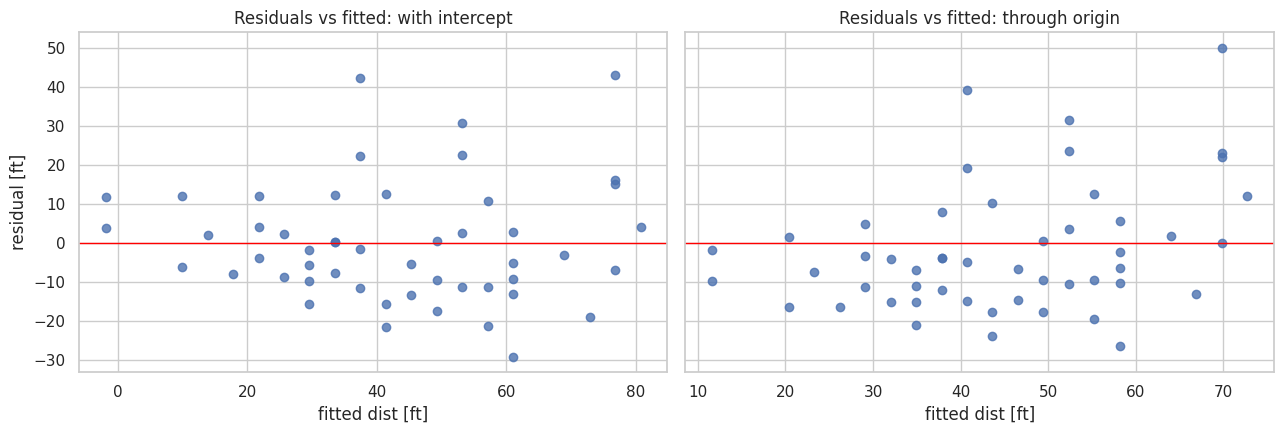

In [9]:
# your solution
fit1 = b0 + b1 * x
fit0 = b1_0 * x

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)

for ax, f, r, t in [(axes[0], fit1, res1, 'with intercept'),
                    (axes[1], fit0, res0, 'through origin')]:
    ax.scatter(f, r, alpha=0.8)
    ax.axhline(0, color='red', lw=1)
    ax.set_title(f'Residuals vs fitted: {t}')
    ax.set_xlabel('fitted dist [ft]')
axes[0].set_ylabel('residual [ft]')

plt.tight_layout()
plt.show()

Neither pattern looks really healthy, but the model with intercept is the better of the two. Its residuals fall on both sides of zero over the whole range, with no clear one-way trend, whereas in the origin model they drift from mostly negative at small fitted values to positive at large ones.

In both models the spread of the residuals grows with the fitted values, so the error variance is not constant, and a few large positive residuals stand out.

## Task 10 - An artificial outlier
Add one artificial outlier (for example a large stopping distance at a low speed) and refit both models. How do the coefficients change? Which model is more sensitive?

In [10]:
# your solution
outlier = pd.DataFrame({'speed': [5], 'dist': [120]})
cars_out = pd.concat([cars, outlier], ignore_index=True)

m1_out = smf.ols('dist ~ speed', data=cars_out).fit()
m0_out = smf.ols('dist ~ speed - 1', data=cars_out).fit()

comp = pd.DataFrame({
    'original': [m1.params['Intercept'], m1.params['speed'], m0.params['speed']],
    'with outlier': [m1_out.params['Intercept'], m1_out.params['speed'], m0_out.params['speed']],
}, index=['intercept model: b0', 'intercept model: b1', 'origin model: b1'])
comp['change'] = comp['with outlier'] - comp['original']
print(comp.round(3))

                     original  with outlier  change
intercept model: b0   -17.579        -2.889  14.690
intercept model: b1     3.932         3.118  -0.815
origin model: b1        2.909         2.949   0.040


Adding the point (5 mph, 120 ft) moves $\hat\beta_0$ from −17.6 to −2.9 and $\hat\beta_1$ from 3.93 to 3.12, while the slope of the origin model changes only from 2.909 to 2.949.

The model with intercept is therefore far more sensitive to this outlier, because the point lies far from the mean speed and rotates the line, whereas at a low speed it carries almost no weight in the origin model.

## Task 11 - Is a straight line adequate?
Reflect on whether a straight-line model in `speed` is an adequate description. Physics suggests that braking distance grows with the square of speed. Suggest at least two possible next steps (a transformation of a variable, an additional term, ...) and try one of them. Transformations and checking model adequacy are the subject of later lectures; a short reflection and one experiment are enough here.

A straight line cannot be the right form, because the stopping distance is the sum of a reaction part proportional to speed and a braking part proportional to its square. Two possible next steps are to add a quadratic term, $dist = a \cdot speed + b \cdot speed^2$, without intercept so that $dist(0) = 0$, or to transform the response, for example $\sqrt{dist}$ against speed. I try the first one.

fitted model: dist = 1.239 * speed + 0.0901 * speed^2
SSE: linear 11354, physics 10831


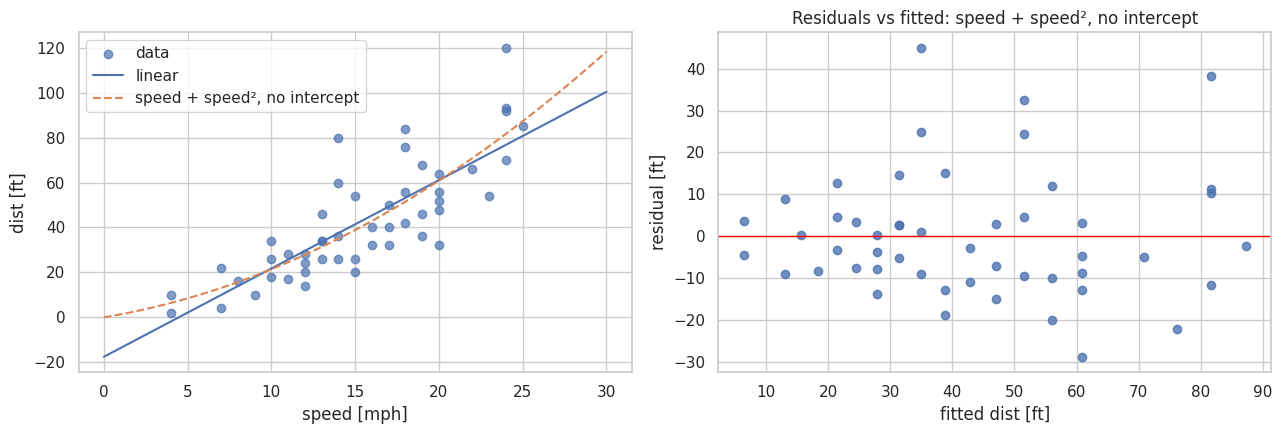

In [11]:
# your solution
cars_q = cars.assign(speed2=cars['speed']**2)
m_phys = smf.ols('dist ~ speed + speed2 - 1', data=cars_q).fit()   # dist = a*speed + b*speed²

a, b = m_phys.params['speed'], m_phys.params['speed2']
print(f'fitted model: dist = {a:.3f} * speed + {b:.4f} * speed^2')
print(f'SSE: linear {m1.ssr:.0f}, physics {m_phys.ssr:.0f}')

grid = np.linspace(0, 30, 200)
g = pd.DataFrame({'speed': grid, 'speed2': grid**2})

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].scatter(x, y, alpha=0.7, label='data')
axes[0].plot(grid, m1.predict(g), label='linear')
axes[0].plot(grid, m_phys.predict(g), '--', label='speed + speed², no intercept')
axes[0].set_xlabel('speed [mph]')
axes[0].set_ylabel('dist [ft]')
axes[0].legend()

axes[1].scatter(m_phys.fittedvalues, m_phys.resid, alpha=0.8)
axes[1].axhline(0, color='red', lw=1)
axes[1].set_title('Residuals vs fitted: speed + speed², no intercept')
axes[1].set_xlabel('fitted dist [ft]')
axes[1].set_ylabel('residual [ft]')

plt.tight_layout()
plt.show()

The model $dist = a \cdot speed + b \cdot speed^2$ has the same number of parameters as the straight line but a smaller SSE (10831 vs 11354), and it satisfies $dist(0) = 0$. Its residuals no longer drift in one direction, but they are still more spread out at higher speeds.

A straight line is therefore a usable approximation within 4–25 mph, but not the right functional form, and the two curves already differ noticeably beyond the observed range.